
# Homography Transformations

## About Homography

Homography allows us to relate one plane to another. This can be used for
- recovering camera pose
- perspective transformation
- overlaying AR objects onto real-world planes
- and more

In NBA2NBA, we can use homography to map the court keypoints to the court coordinates, enabling us to have a top-down view of the court. Combined with bounding box detection, we can use this to estimate a big picture view of a possession on the court.

Let $H \in \mathbb{R}^{3 \times 3}$ be a homography matrix. $H$ transforms a point $x \in \mathbb{R}^{2}$ to a point $x' \in \mathbb{R}^{2}$ scaled by $s_i$.
$$
H = \begin{bmatrix}
    h_{11} & h_{12} & h_{13} \\
    h_{21} & h_{22} & h_{23} \\
    h_{31} & h_{32} & h_{33}
\end{bmatrix}
\qquad
s_i \begin{bmatrix}
    x_i' \\
    y_i' \\
    1
\end{bmatrix}
= H \begin{bmatrix}
    x_i \\
    y_i \\
    1
\end{bmatrix}
$$

So taking the product,
$$
\begin{align*}
H \begin{bmatrix}
x_i\\
y_i\\
1
\end{bmatrix} &= \begin{bmatrix}
h_{11} x_i + h_{12} y_i + h_{13}\\
h_{21} x_i + h_{22} y_i + h_{23}\\
h_{31} x_i + h_{32} y_i + h_{33}
\end{bmatrix}\\
\implies s_i \begin{bmatrix}
x_i'\\
y_i'\\
1
\end{bmatrix} &= \begin{bmatrix}
h_{11} x_i + h_{12} y_i + h_{13}\\
h_{21} x_i + h_{22} y_i + h_{23}\\
h_{31} x_i + h_{32} y_i + h_{33}
\end{bmatrix} \\
\end{align*}
$$
And setting $s_i = h_{31} x_i + h_{32} y_i + h_{33}$, we can directly solve for $x_i'$ and $y_i'$.
$$
\implies 
\begin{bmatrix}
x_i'\\
y_i'\\
1
\end{bmatrix} = \begin{bmatrix}
\frac{h_{11} x_i + h_{12} y_i + h_{13}}{h_{31} x_i + h_{32} y_i + h_{33}}\\
\frac{h_{21} x_i + h_{22} y_i + h_{23}}{h_{31} x_i + h_{32} y_i + h_{33}}\\
1
\end{bmatrix}
$$

This means the *back-projection* (reconstruction/squared) error of the homography is 
$$
\sum_i \left(x_i' - \frac{h_{11} x_i + h_{12} y_i + h_{13}}{h_{31} x_i + h_{32} y_i + h_{33}}\right)^2 + \left(y_i' - \frac{h_{21} x_i + h_{22} y_i + h_{23}}{h_{31} x_i + h_{32} y_i + h_{33}}\right)^2
$$

For reference, see [OpenCV Homography Documentation](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html) and `findHomography()` which solves for the homography matrix given corresponding points in two images.
- `findHomography()` uses the RANSAC algorithm to optimize $H$ between corresponding points in two images
- RANSAC iterates $n$ times over samples of points to find the best fit homography matrix using back-projection error threshold (iteratively comparing and storing best performing homography matrix)

## Imports + Installs

In [1]:
%pip -V

pip 25.3 from /Users/rjunw/Desktop/dev/nba2nba/.venv/lib/python3.11/site-packages/pip (python 3.11)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# sys deps
import os
from dotenv import load_dotenv

# homography deps
import cv2
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
import pillow_avif
from court import Court

# model deps
import supervision as sv
from roboflow import Roboflow
from ultralytics import YOLO
from rfdetr import RFDETRMedium

from tqdm import tqdm

# env vars
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

# model vars
YOLOv11x_CHECKPOINT = "../models/weights/yolov11x_kpd/checkpoint_best_total.pt"
RF_DETR_MEDIUM_CHECKPOINT = "../models/weights/rf_detr_od/checkpoint_best_total.pth"

# dataset paths
player_od_data = "../data/.cache/bball_od"
court_kpd_data = "../data/.cache/bball_court_kpd"

## Helpers

## Loading Models

In [ ]:
od_model = RFDETRMedium(pretrain_weights=RF_DETR_MEDIUM_CHECKPOINT)
od_model.optimize_for_inference() # compile model for faster inference
kpd_model = YOLO(YOLOv11x_CHECKPOINT, task='pose')

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 5 classes, but your model has 90 classes
reinitializing detection head with 5 classes


Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors 

In [ ]:
# defining a dataset iterator
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{player_od_data}/test",
    annotations_path=f"{player_od_data}/test/_annotations.coco.json",
)

Let's make sure our models are working.

  0%|          | 0/169 [00:00<?, ?it/s]


0: 640x640 1 court, 412.7ms
Speed: 3.5ms preprocess, 412.7ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)


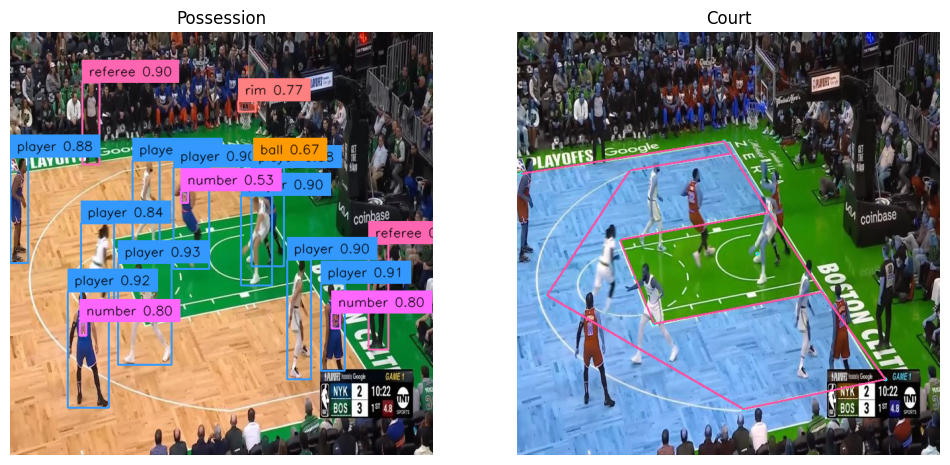

 11%|█         | 19/169 [00:00<00:07, 19.09it/s]


In [5]:
test_images = os.listdir(player_od_data + "/test/")
i = 1
for path, image, annotations in tqdm(ds):
    
    if i % 20 == 0:
        # inference
        image = Image.open(path)
        od_detections = od_model.predict(image)
        kpd_detections = kpd_model(image)

        # plotting schtuff
        image_court = Court()
        text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
        thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
        color = sv.ColorPalette.from_hex([
            "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
            "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
        ])

        # OD 
        bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
        label_annotator = sv.LabelAnnotator(
            color=color,
            text_color=sv.Color.BLACK,
            text_scale=text_scale)

        detections_labels = [
            f"{ds.classes[class_id]} {confidence:.2f}"
            for class_id, confidence
            in zip(od_detections.class_id, od_detections.confidence)
        ]

        detections_image = image.copy()
        detections_image = bbox_annotator.annotate(detections_image, od_detections)
        detections_image = label_annotator.annotate(detections_image, od_detections, detections_labels)

        # KPD
        # get kp object via supervision
        key_points = sv.KeyPoints.from_ultralytics(kpd_detections[0])

        # filter out low confidence key points
        kp_to_keep = key_points.confidence > 0.1

        # build a filtered key point object
        kp_ids = np.array([i for i in range(key_points.confidence.shape[1])])[kp_to_keep.flatten()]

        # filter down edge list to what we have
        image_court.kp_edge_list = [(edge[0]+1, edge[1]+1) for edge in image_court.kp_edge_list if edge[0] in set(kp_ids) and edge[1] in set(kp_ids)]

        kp_thresholded = key_points.xy[kp_to_keep]
        kp_confidence_thresholded = key_points.confidence[kp_to_keep]
        thresholded_key_points = sv.KeyPoints(
            xy=kp_thresholded.reshape(-1,*kp_thresholded.shape),
            class_id=key_points.class_id,
            confidence=kp_confidence_thresholded.reshape(-1,*kp_confidence_thresholded.shape)
        )

        # just plotting stuff
        kpd_image = cv2.imread(path)

        # annotate keypoints
        vertex_annotator = sv.VertexAnnotator(radius=3, color=sv.Color.YELLOW)
        kpd_image = vertex_annotator.annotate(
            scene=kpd_image,
            key_points=thresholded_key_points)

        # annotate edges
        edge_annotator = sv.EdgeAnnotator(thickness=2, edges=image_court.kp_edge_list)
        kpd_image = edge_annotator.annotate(
            scene=kpd_image,
            key_points=key_points)

        kpd_image = sv.resize_image(
            kpd_image,
            resolution_wh=(640, 640), # keep same as model input size for easier viz
            keep_aspect_ratio=True
        )

        # convert to RGB
        kpd_image = cv2.cvtColor(kpd_image, cv2.COLOR_BGR2RGB)
        sv.plot_images_grid(images=[detections_image, kpd_image], grid_size=(1, 2), titles=["Possession", "Court"])
        break
    i += 1


## Homography

First, let's define the court we want to project to.

(35, 34)
(576, 348)


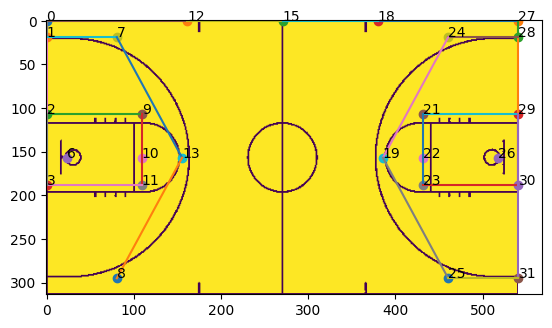

In [148]:
# the court we want to project to
# it's not a perfect match, but it's close enough
td_court = Image.open("../assets/istockphoto-1345283388-612x612.jpg")
td_court = td_court.convert("L")
td_court = td_court.point( lambda p: 255 if p > 200 else 0 )
td_court_arr = np.array(td_court)

top_left = (0, 0)
found_top_left = False
for r in range(td_court_arr.shape[0]):
    for c in range(td_court_arr.shape[1]):
        if td_court_arr[r, c] != 255:
            top_left = (c, r)
            found_top_left = True
            break
    if found_top_left:
        break

bottom_right = (td_court_arr.shape[1] - 1, td_court_arr.shape[0] - 1)
found_bottom_right = False
for r in range(td_court_arr.shape[0] - 1, -1, -1):
    for c in range(td_court_arr.shape[1] - 1, -1, -1):
        if td_court_arr[r, c] != 255:
            bottom_right = (c, r)
            found_bottom_right = True
            break
    if found_bottom_right:
        break

print(top_left)
print(bottom_right)

td_court = td_court.crop((top_left[0], top_left[1], bottom_right[0], bottom_right[1]))
td_court_arr = np.array(td_court)
width = td_court_arr.shape[1]
height = td_court_arr.shape[0]

plt.imshow(td_court)
ball_court = Court(width=width, height = height)

for idx, coord in ball_court.kp_coordinates.items():
    plt.scatter(coord[0], coord[1])
    plt.text(coord[0], coord[1], idx)
for edge in ball_court.kp_edge_list:
    plt.plot([ball_court.kp_coordinates[edge[0]][0], ball_court.kp_coordinates[edge[1]][0]], [ball_court.kp_coordinates[edge[0]][1], ball_court.kp_coordinates[edge[1]][1]])

plt.show()

Now we can perform homography!

  0%|          | 0/169 [00:00<?, ?it/s]


0: 640x640 1 court, 558.7ms
Speed: 3.7ms preprocess, 558.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


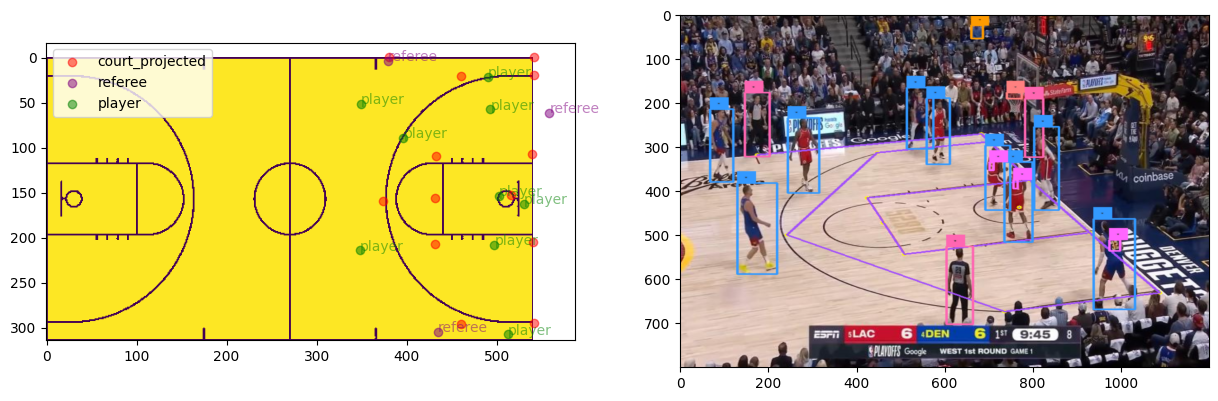

 12%|█▏        | 21/169 [00:01<00:08, 16.90it/s]


0: 640x640 1 court, 363.7ms
Speed: 1.6ms preprocess, 363.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


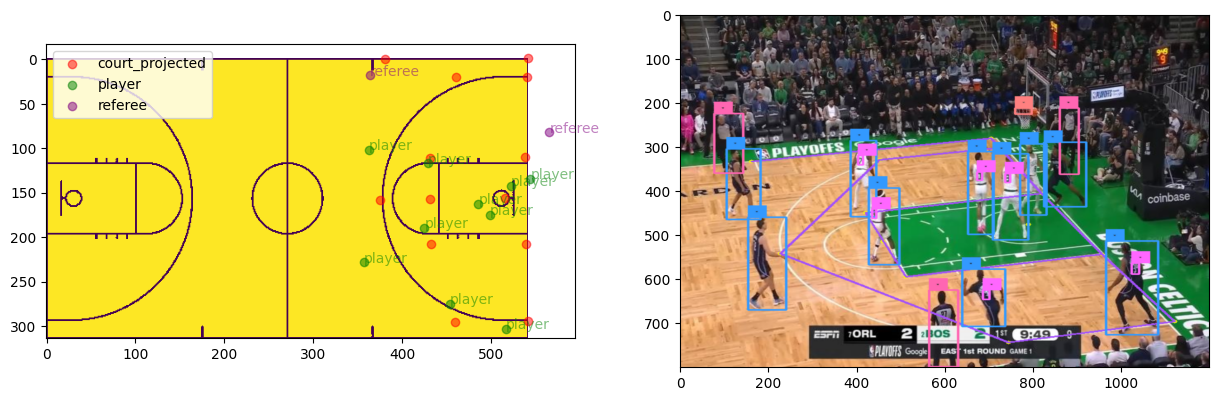

 15%|█▌        | 26/169 [00:02<00:11, 12.00it/s]


0: 640x640 1 court, 325.0ms
Speed: 1.6ms preprocess, 325.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


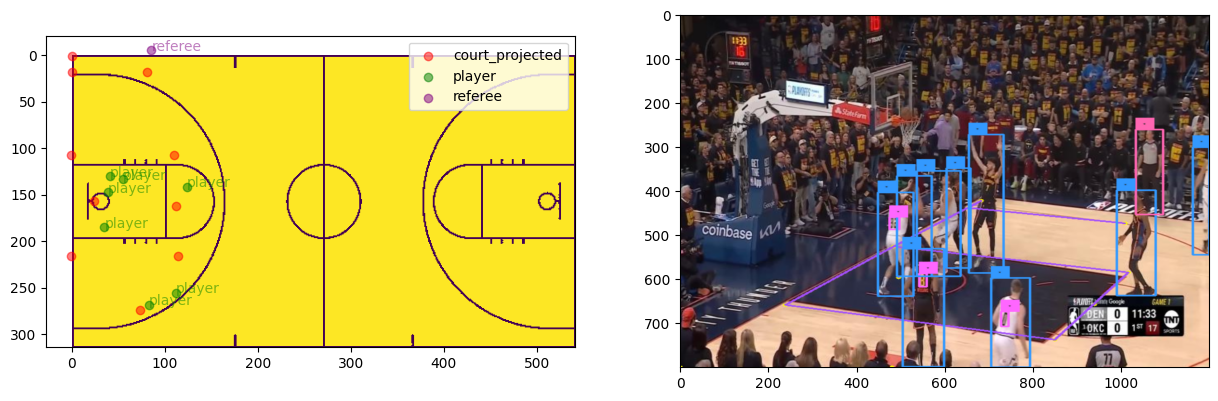

 27%|██▋       | 45/169 [00:02<00:06, 18.97it/s]


0: 640x640 1 court, 475.1ms
Speed: 3.4ms preprocess, 475.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


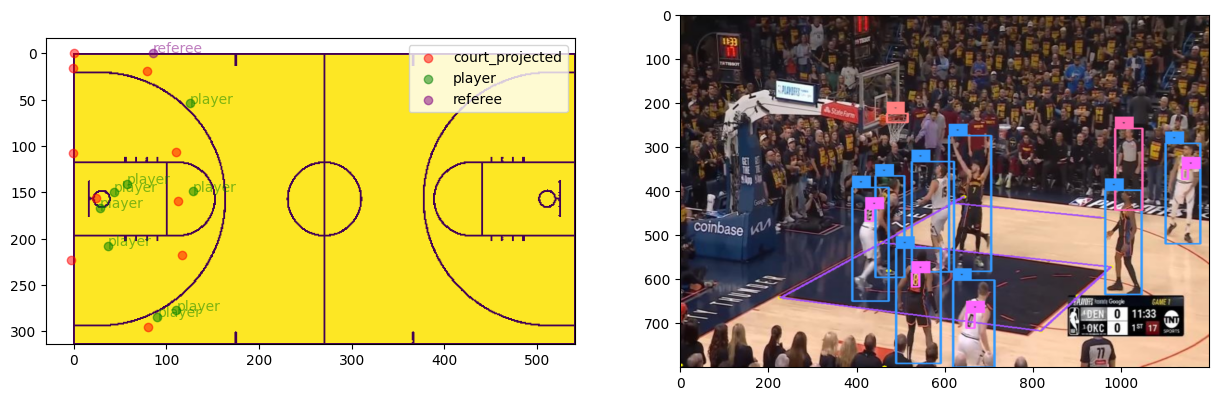

 38%|███▊      | 65/169 [00:03<00:04, 21.40it/s]


0: 640x640 1 court, 348.6ms
Speed: 1.3ms preprocess, 348.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


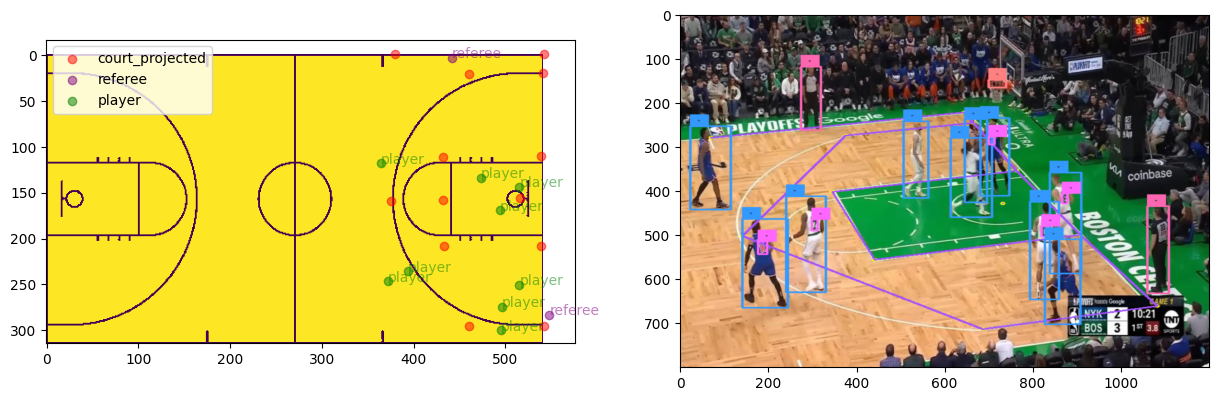

 50%|█████     | 85/169 [00:04<00:03, 23.97it/s]


0: 640x640 1 court, 335.2ms
Speed: 1.1ms preprocess, 335.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


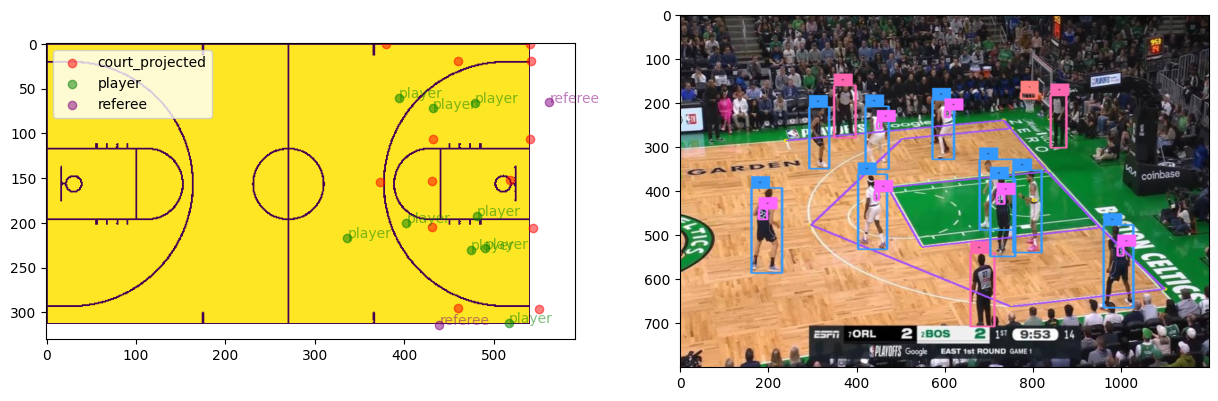

 62%|██████▏   | 105/169 [00:05<00:02, 25.79it/s]


0: 640x640 1 court, 367.6ms
Speed: 2.2ms preprocess, 367.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


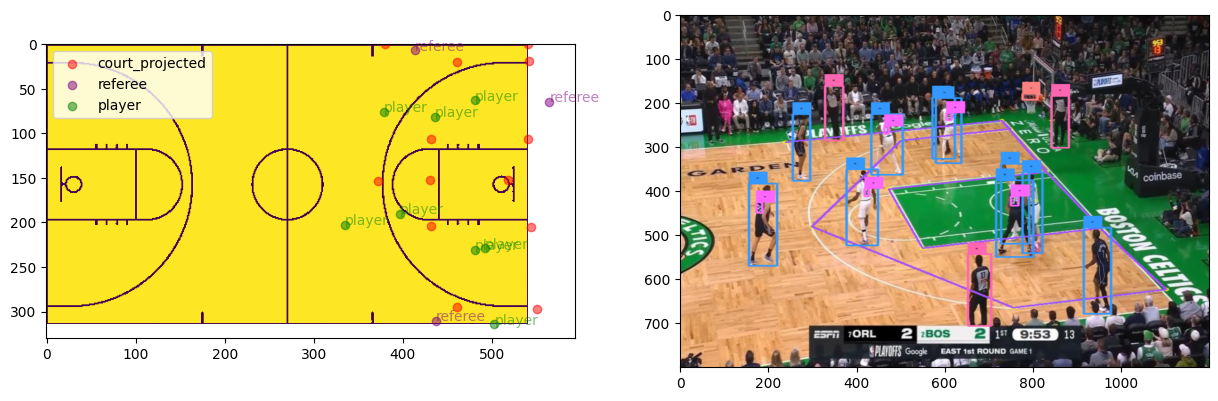

 74%|███████▍  | 125/169 [00:05<00:01, 25.61it/s]


0: 640x640 1 court, 337.5ms
Speed: 1.3ms preprocess, 337.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


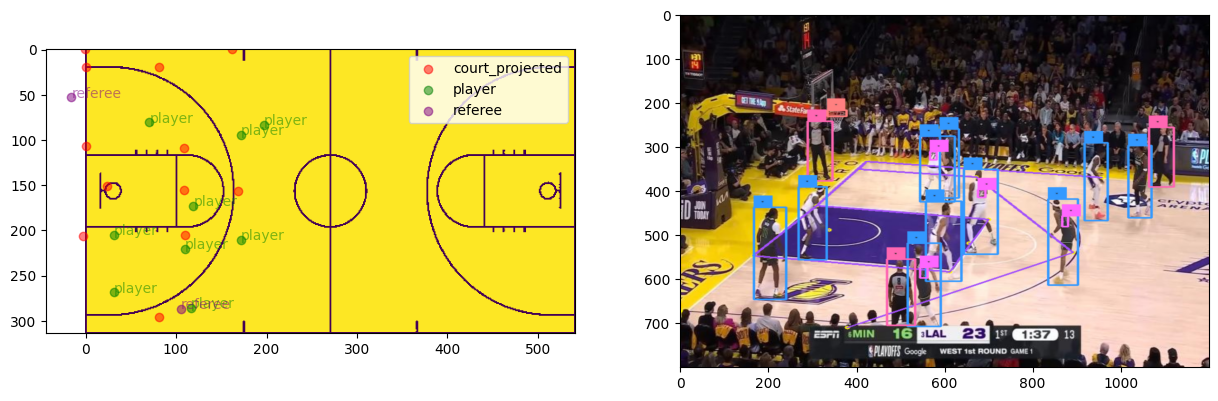

 86%|████████▌ | 145/169 [00:06<00:00, 26.55it/s]


0: 640x640 1 court, 437.5ms
Speed: 1.7ms preprocess, 437.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


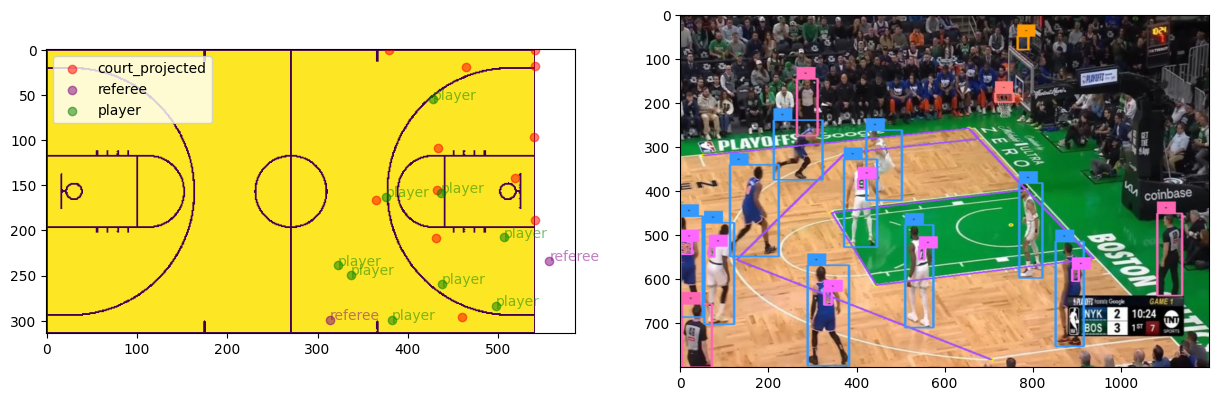

100%|██████████| 169/169 [00:07<00:00, 22.76it/s]


In [ ]:
for path, image, annotations in tqdm(ds):
    
    if i % 20 == 0:
        # inference
        image_court = Court()
        image = cv2.imread(path)
        od_detections = od_model.predict(image)
        kpd_detections = kpd_model(image)

        # kp coords
        key_points = sv.KeyPoints.from_ultralytics(kpd_detections[0])
        kp_to_keep = key_points.confidence > 0.1
        kp_ids = np.array([i for i in range(key_points.confidence.shape[1])])[kp_to_keep.flatten()]
        image_court.kp_edge_list = [(edge[0]+1, edge[1]+1) for edge in image_court.kp_edge_list if edge[0] in set(kp_ids) and edge[1] in set(kp_ids)]
        kp_thresholded = key_points.xy[kp_to_keep]

        kp_confidence_thresholded = key_points.confidence[kp_to_keep]
        thresholded_key_points = sv.KeyPoints(
            xy=kp_thresholded.reshape(-1,*kp_thresholded.shape),
            class_id=key_points.class_id,
            confidence=kp_confidence_thresholded.reshape(-1,*kp_confidence_thresholded.shape)
        )        

        # filter out any points that are not in court
        id_kp = []
        for idx, kp in zip(kp_ids, kp_thresholded):
            if idx in image_court.kp_coordinates:
                id_kp.append((idx, kp))

        ###### perform homography ######
        # ON COURT
        source = np.array([x for _, x in id_kp])
        source = np.concatenate([source, np.ones((source.shape[0], 1))], axis=1)
        destination = np.array([ball_court.kp_coordinates[int(idx)] for idx in kp_ids if idx in ball_court.kp_coordinates])
        destination = np.concatenate([destination, np.ones((destination.shape[0], 1))], axis=1)

        H, _ = cv2.findHomography(source, destination, cv2.RANSAC)
        projected = H @ source.T
        projected = projected.T

        # ON PLAYERS
        mean_player_pos = np.concatenate(
            [od_detections.xyxy[:, [0, 2]].mean(axis=1).reshape(-1, 1),
            od_detections.xyxy[:, 3].reshape(-1, 1),
            np.ones((od_detections.xyxy.shape[0], 1))],
            axis=1
        )
        mean_player_pos_projected = H @ mean_player_pos.T
        mean_player_pos_projected = mean_player_pos_projected.T

        ###### build plots ######
        plt.figure(figsize=(15, 7))

        # HOMOGRAPHY PLOT
        plt.subplot(1, 2, 1)
        plt.imshow(td_court)

        # for idx, coord in zip(kp_ids, destination):
            # plt.scatter(coord[0]/coord[2], coord[1]/coord[2], color="blue", alpha = 0.5, label = 'court_actual')
            # plt.text(coord[0]/coord[2], coord[1]/coord[2], idx, color='blue', alpha = 0.5)

        for idx, coord in zip(kp_ids, projected):
            plt.scatter(coord[0]/coord[2], coord[1]/coord[2], color="red", alpha = 0.5, label = 'court_projected')
            # plt.text(coord[0]/coord[2], coord[1]/coord[2], idx, color='red', alpha = 0.5)

        for idx, coord, class_id in zip(kp_ids, mean_player_pos_projected, od_detections.class_id):
            if ds.classes[class_id] == 'player':
                class_color = 'green'
            elif ds.classes[class_id] == 'ball':
                class_color = 'orange' 
            elif ds.classes[class_id] == 'referee':
                class_color = 'purple'
            else:
                continue
            plt.scatter(coord[0]/coord[2], coord[1]/coord[2], color=class_color, alpha = 0.5, label = ds.classes[class_id])
            plt.text(coord[0]/coord[2], coord[1]/coord[2], ds.classes[class_id], color=class_color, alpha = 0.5)

        # remove duplicate labels
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        ###### KPD+OD PLOT ######
        kpd_image = cv2.imread(path)
        text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.shape)
        thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.shape)
        color = sv.ColorPalette.from_hex([
            "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
            "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
        ])
        
        # annotate keypoints
        vertex_annotator = sv.VertexAnnotator(radius=3, color=sv.Color.YELLOW)
        kpd_image = vertex_annotator.annotate(scene=kpd_image, key_points=thresholded_key_points)

        # annotate edges
        edge_annotator = sv.EdgeAnnotator(thickness=2, edges=image_court.kp_edge_list)
        kpd_image = edge_annotator.annotate(scene=kpd_image, key_points=key_points)

        # annotate bbox
        bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
        detections_labels = [
            f"{ds.classes[class_id]} {confidence:.2f}"
            for class_id, confidence
            in zip(od_detections.class_id, od_detections.confidence)
        ]
        kpd_image = bbox_annotator.annotate(kpd_image, od_detections)

        # annotate labels
        label_annotator = sv.LabelAnnotator(
            color=color,
            text_color=sv.Color.BLACK,
            text_scale=text_scale)
        label_annotator.annotate(kpd_image, od_detections, detections_labels)

        kpd_image = sv.resize_image(
            kpd_image,
            resolution_wh=(1200, 800), # keep same as model input size for easier viz
            keep_aspect_ratio=False
        )

        # convert to RGB
        kpd_image = cv2.cvtColor(kpd_image, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 2, 2)
        plt.imshow(kpd_image)
        plt.show()

    i += 1